## Title: Analysis of Cholera Cases in different countries ##
*Author: Malambo Muloongo*

*Location: Lusaka, Zambia*

*Date: 19/04/2026*

*Time: 01:50 AM*

*Source of the Data: Kaggle[https://www.kaggle.com/datasets/imdevskp/cholera-dataset/data]*


**Introduction**

Cholera is a severe diarrhoeal disease that occurs after consuming food or water contaminated with the bacterium Vibrio cholerae. It continues to pose a significant global public health challenge and is often seen as a marker of social inequality and inadequate development. Estimates suggest that each year there are approximately 1.3 to 4.0 million cases worldwide, resulting in between 21,000 and 143,000 deaths.

**Import required packages**

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Style
sns.set(style="whitegrid")

**Loading and preview of the cholare data**

In [87]:
df = pd.read_csv("malaria_data.csv")

print("\n=== DATA PREVIEW ===")
print(df.head())


=== DATA PREVIEW ===
       Country  Year Number of reported cases of cholera  \
0  Afghanistan  2016                                 677   
1  Afghanistan  2015                               58064   
2  Afghanistan  2014                               45481   
3  Afghanistan  2013                                3957   
4  Afghanistan  2012                                  12   

  Number of reported deaths from cholera Cholera case fatality rate  \
0                                      5                        0.7   
1                                      8                       0.01   
2                                      4                          0   
3                                     14                       0.35   
4                                      0                        0.1   

              WHO Region  
0  Eastern Mediterranean  
1  Eastern Mediterranean  
2  Eastern Mediterranean  
3  Eastern Mediterranean  
4  Eastern Mediterranean  


In [9]:
df.columns

Index(['Country', 'Year', 'Number of reported cases of cholera',
       'Number of reported deaths from cholera', 'Cholera case fatality rate',
       'WHO Region'],
      dtype='object')

In [12]:
df.dtypes

Country                                   object
Year                                       int64
Number of reported cases of cholera       object
Number of reported deaths from cholera    object
Cholera case fatality rate                object
WHO Region                                object
dtype: object

In [88]:
country_list=df.Country.unique()
len(df.Country.unique())

162

In [89]:
# Clean and convert to numeric
cols = [
    'Number of reported cases of cholera',
    'Number of reported deaths from cholera'
]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)              # ensure string first
        .str.replace(',', '')     # remove thousand separators
        .str.strip()              # remove spaces
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

**Data cleaning**

In [90]:
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# Fill missing values
df.fillna(0, inplace=True)

# Create new variables
df['recoveries'] = df['Number of reported cases of cholera'] - df['Number of reported deaths from cholera']
df['recovery_rate'] = df['recoveries'] / df['Number of reported cases of cholera']
df['mortality_rate'] = df['Number of reported deaths from cholera'] / df['Number of reported cases of cholera']

# Handle division issues
df.replace([float('inf'), -float('inf')], 0, inplace=True)
df.fillna(0, inplace=True)


=== MISSING VALUES ===
Country                                     0
Year                                        0
Number of reported cases of cholera        23
Number of reported deaths from cholera    119
Cholera case fatality rate                127
WHO Region                                  0
dtype: int64


In [91]:
df['Year'].unique

<bound method Series.unique of 0       2016
1       2015
2       2014
3       2013
4       2012
        ... 
2487    1980
2488    1971
2489    1984
2490    1980
2491    2011
Name: Year, Length: 2492, dtype: int64>

**Classify time Period**

In [92]:
def classify_period(year):
    if year <= 2000:
        return "Pre-Outbreak"
    elif year >= 2001 and year <= 2010:
        return "Outbreak"
    else:
        return "Recovery"

df['period'] = df['Year'].apply(classify_period)

In [93]:
df.describe

<bound method NDFrame.describe of                  Country  Year  Number of reported cases of cholera  \
0            Afghanistan  2016                                677.0   
1            Afghanistan  2015                              58064.0   
2            Afghanistan  2014                              45481.0   
3            Afghanistan  2013                               3957.0   
4            Afghanistan  2012                                 12.0   
...                  ...   ...                                  ...   
2487  Russian Federation  1980                                  0.0   
2488  Russian Federation  1971                                  0.0   
2489              Sweden  1984                                  0.0   
2490         Switzerland  1980                                  0.0   
2491            Cambodia  2011                                  0.0   

      Number of reported deaths from cholera Cholera case fatality rate  \
0                                     

In [22]:
df.columns

Index(['Country', 'Year', 'Number of reported cases of cholera',
       'Number of reported deaths from cholera', 'Cholera case fatality rate',
       'WHO Region', 'recoveries', 'recovery_rate', 'mortality_rate',
       'period'],
      dtype='object')

**Period analysis**


=== PERIOD SUMMARY ===
              Number of reported cases of cholera  \
period                                              
Outbreak                                1817582.0   
Pre-Outbreak                            5903666.0   
Recovery                                1459430.0   

              Number of reported deaths from cholera  recoveries  
period                                                            
Outbreak                                     41937.0   1775645.0  
Pre-Outbreak                                836395.0   5067271.0  
Recovery                                     18872.0   1440558.0  


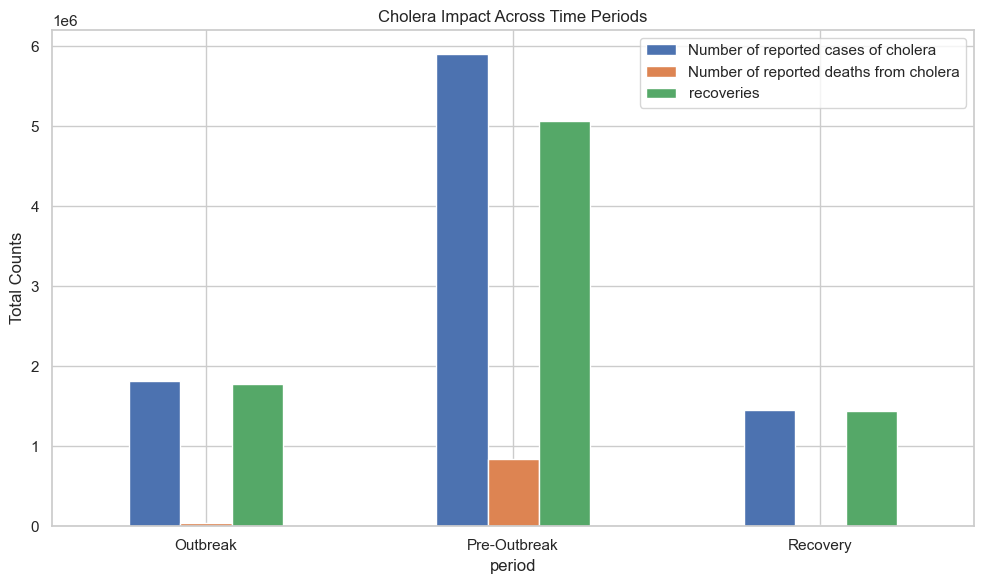

In [94]:
period_summary = df.groupby('period')[['Number of reported cases of cholera', 'Number of reported deaths from cholera', 'recoveries']].sum()

print("\n=== PERIOD SUMMARY ===")
print(period_summary)

# Plot
period_summary.plot(kind='bar', figsize=(10,6))
plt.title("Cholera Impact Across Time Periods")
plt.ylabel("Total Counts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Regional analysis**


=== CASES BY COUNTRY ===
Country
India                               1363250.0
Haiti                                795794.0
Peru                                 736195.0
Democratic Republic of the Congo     521607.0
Indonesia                            394945.0
                                      ...    
Uzbekistan                                1.0
Slovenia                                  0.0
Mauritius                                 0.0
Lesotho                                   0.0
Andorra                                   0.0
Name: Number of reported cases of cholera, Length: 162, dtype: float64


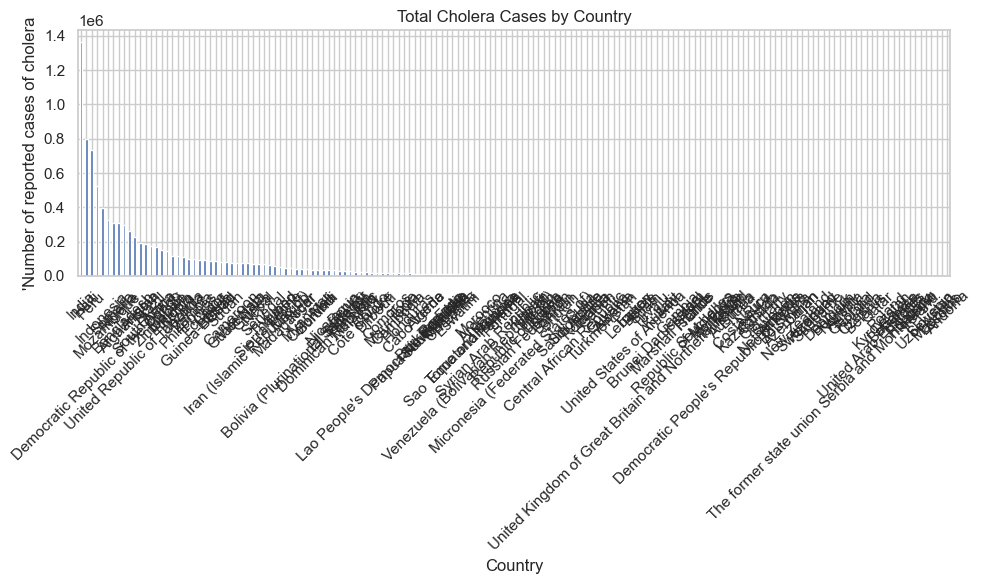

In [95]:

region_summary = df.groupby('Country')['Number of reported cases of cholera'].sum().sort_values(ascending=False)

print("\n=== CASES BY COUNTRY ===")
print(region_summary)

plt.figure(figsize=(10,6))
region_summary.plot(kind='bar')
plt.title("Total Cholera Cases by Country")
plt.ylabel("'Number of reported cases of cholera")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ValueError: num must be an integer with 1 <= num <= 81, not 82

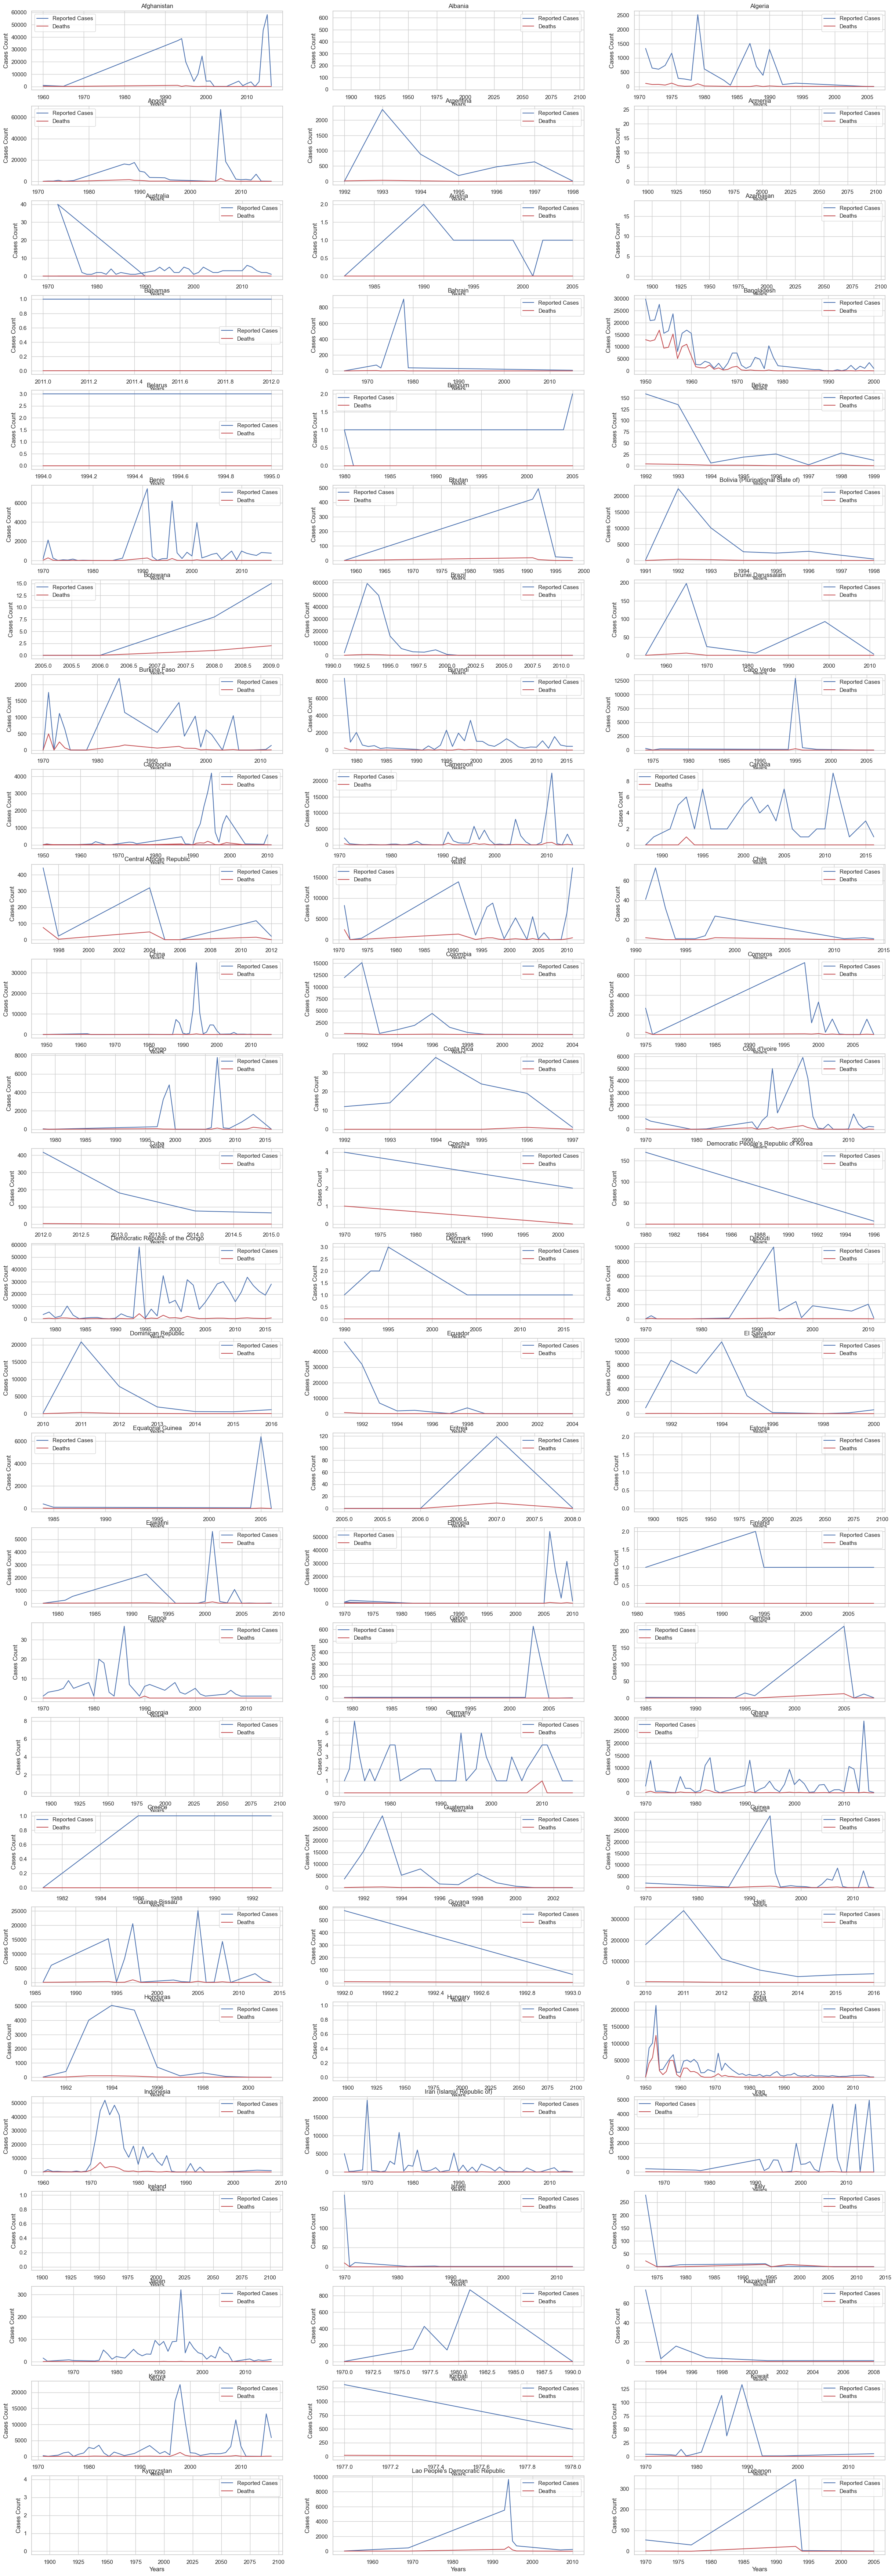

In [97]:
fig = plt.figure(figsize=(30,90))
for c,num in zip(df.Country.unique(), np.arange(1,len(df.Country.unique()))):
    df_req=df[df['Country']==c]
    ax = fig.add_subplot(27,3,num)
    x=df_req['Year']
    y1=pd.to_numeric(df_req['Number of reported cases of cholera'])
    ax.plot(x,y1)
    y2=pd.to_numeric(df_req['Number of reported deaths from cholera'])
    ax.plot(x,y2,color='r')
    ax.legend(['Reported Cases','Deaths'])
    ax.set_title(c)
    ax.set_xlabel('Years')
    ax.set_ylabel('Cases Count')

plt.tight_layout()
plt.show()

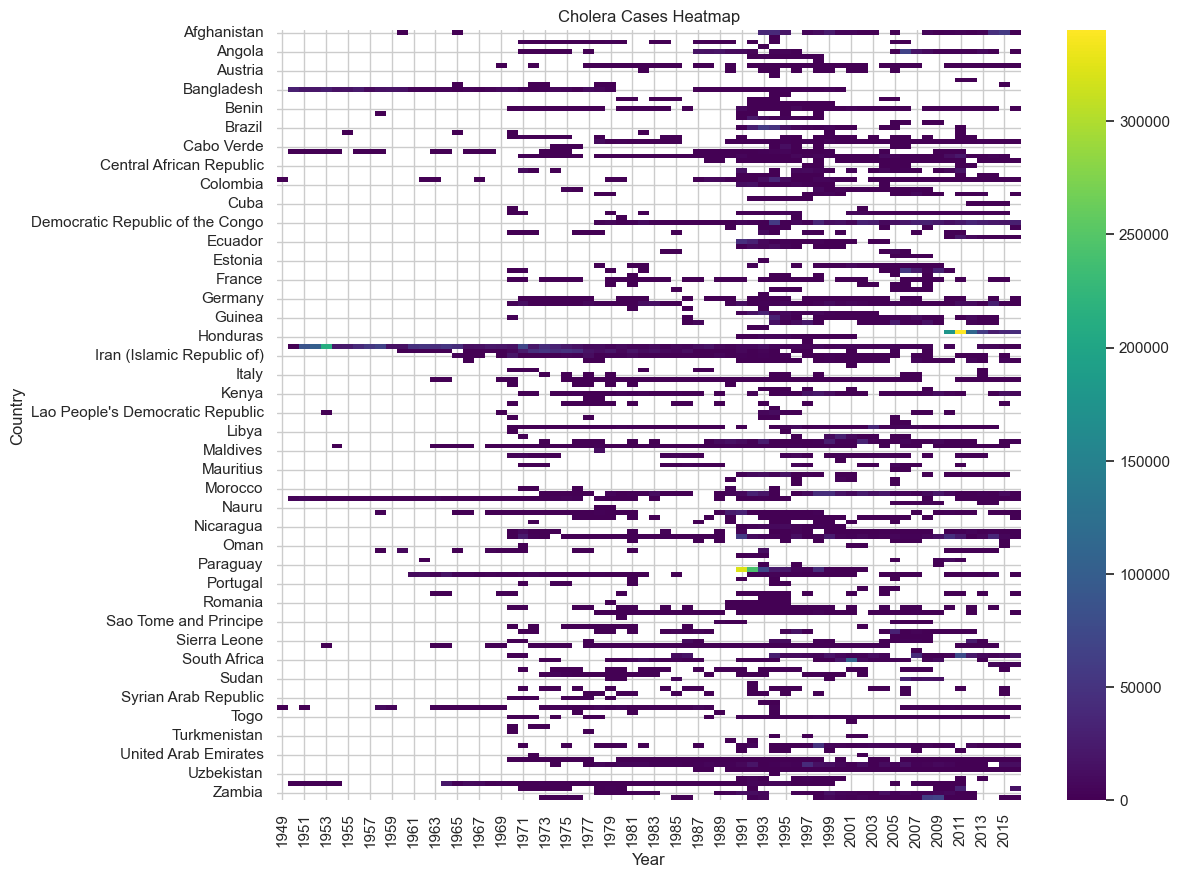

In [98]:
#Heatmap
pivot = df.pivot_table(
    values='Number of reported cases of cholera',
    index='Country',
    columns='Year',
    aggfunc='sum'
)

import seaborn as sns
plt.figure(figsize=(12,10))
sns.heatmap(pivot, cmap='viridis')
plt.title("Cholera Cases Heatmap")
plt.show()

WHO Region wise visualization of Total Number of Reported Cases and Total Number of Deaths over the Years

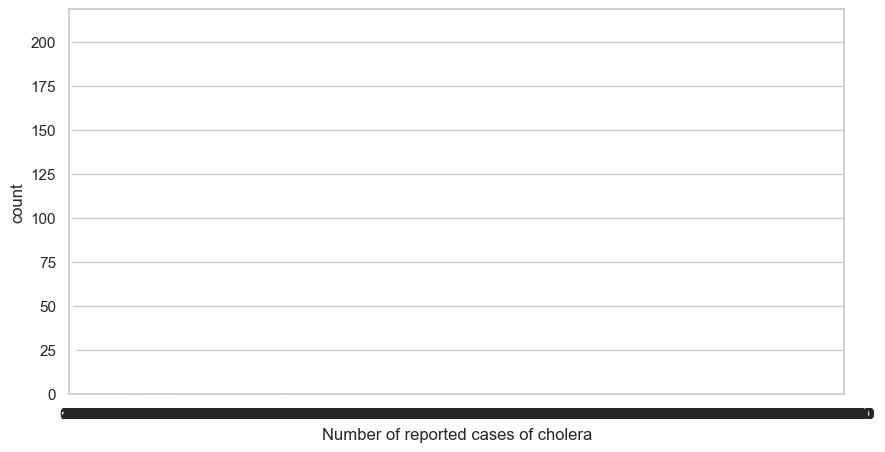

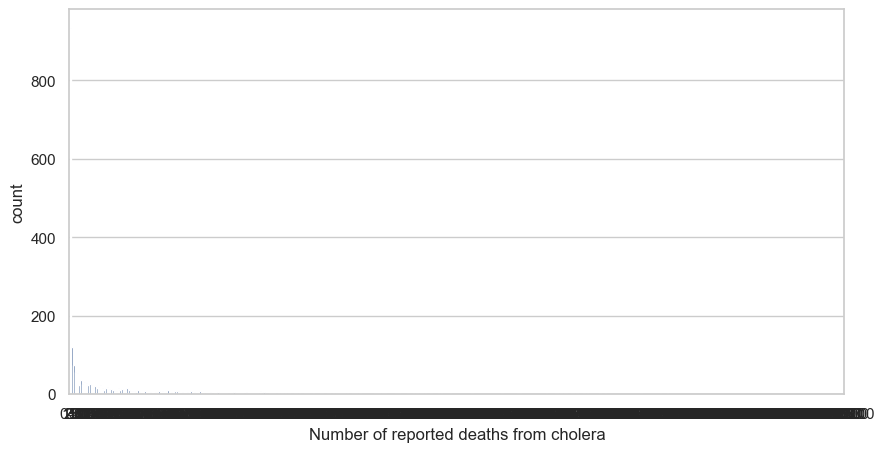

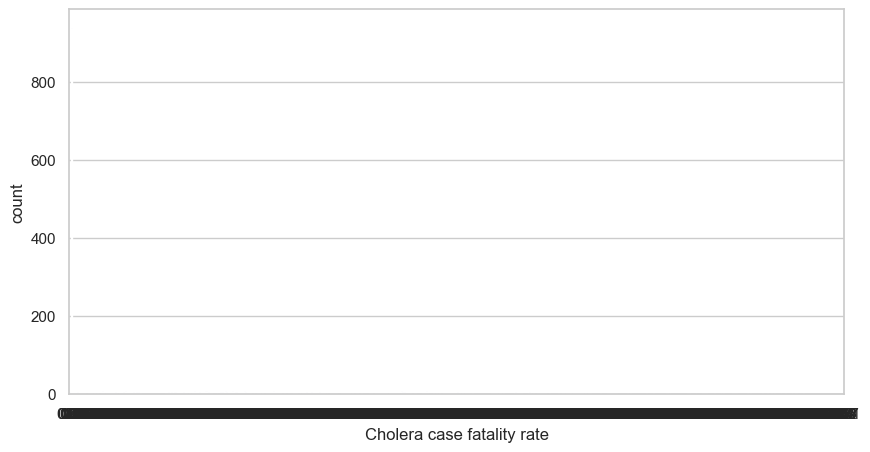

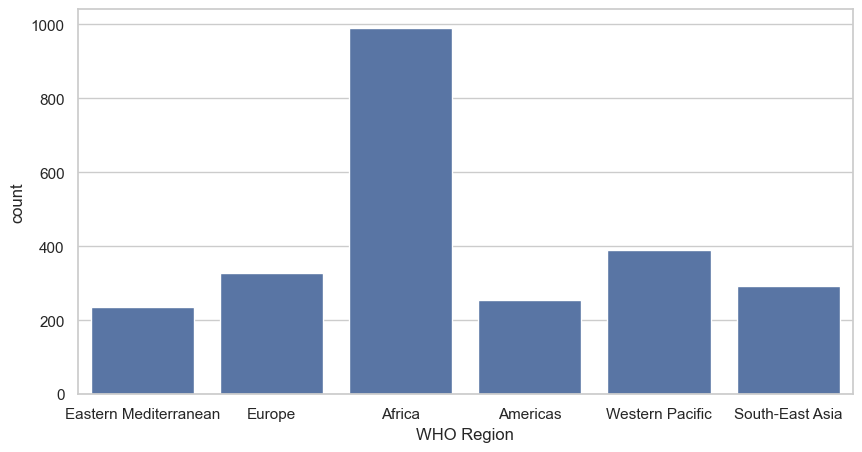

In [99]:
features = ['Number of reported cases of cholera', 'Number of reported deaths from cholera', 'Cholera case fatality rate', 'WHO Region']

for feature in features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=feature)

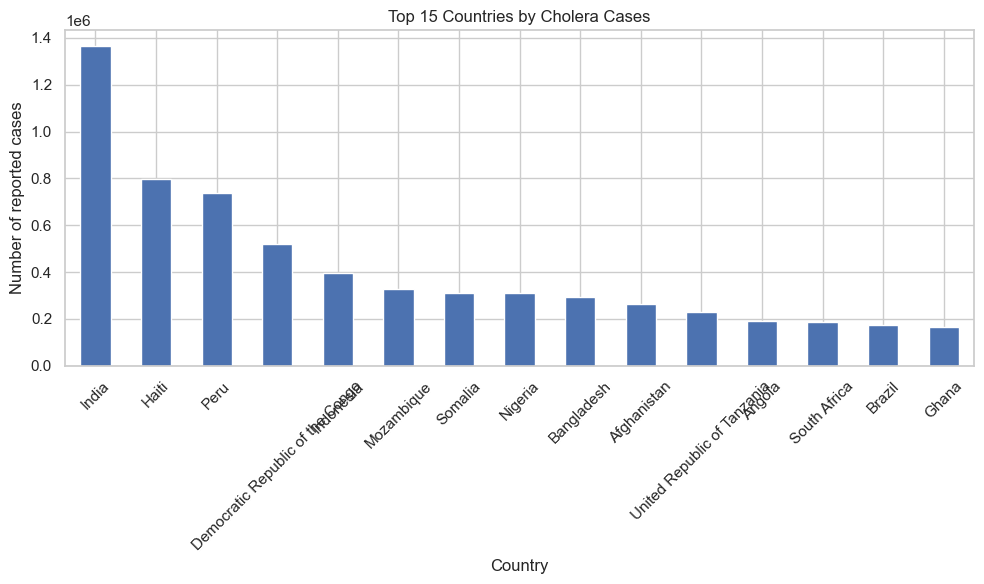

In [100]:
top_n = 15
top_countries = region_summary.head(top_n)

plt.figure(figsize=(10,6))
top_countries.plot(kind='bar')
plt.title(f"Top {top_n} Countries by Cholera Cases")
plt.ylabel("Number of reported cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Recovery rate trend**

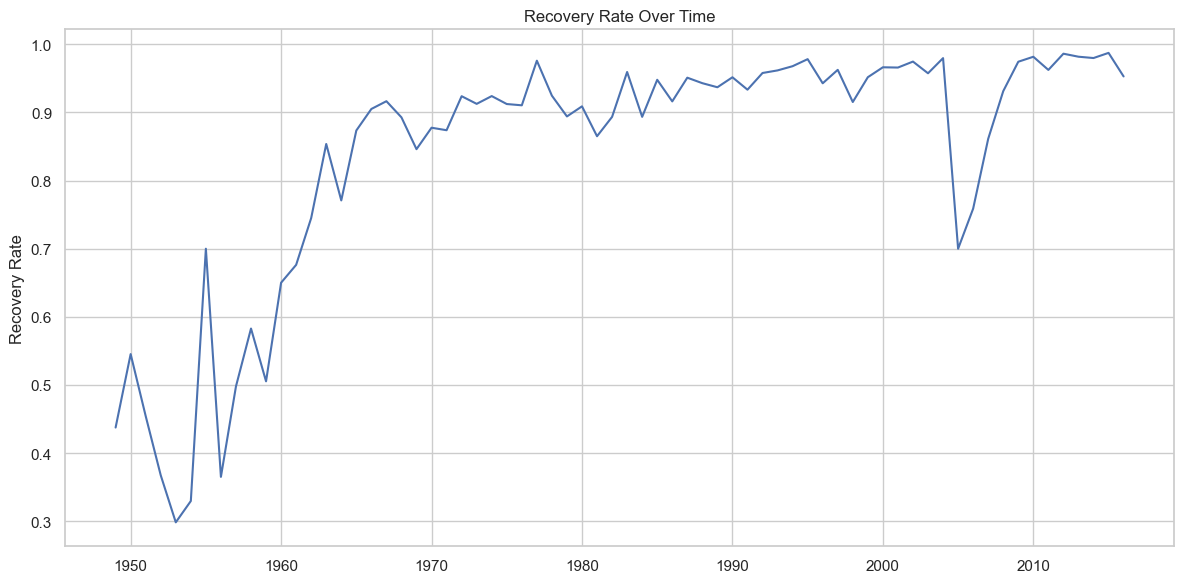

In [101]:

recovery_trend = df.groupby('Year')['recovery_rate'].mean()

plt.figure(figsize=(12,6))
plt.plot(recovery_trend)
plt.title("Recovery Rate Over Time")
plt.ylabel("Recovery Rate")
plt.tight_layout()
plt.show()

**Mortality rate trend**

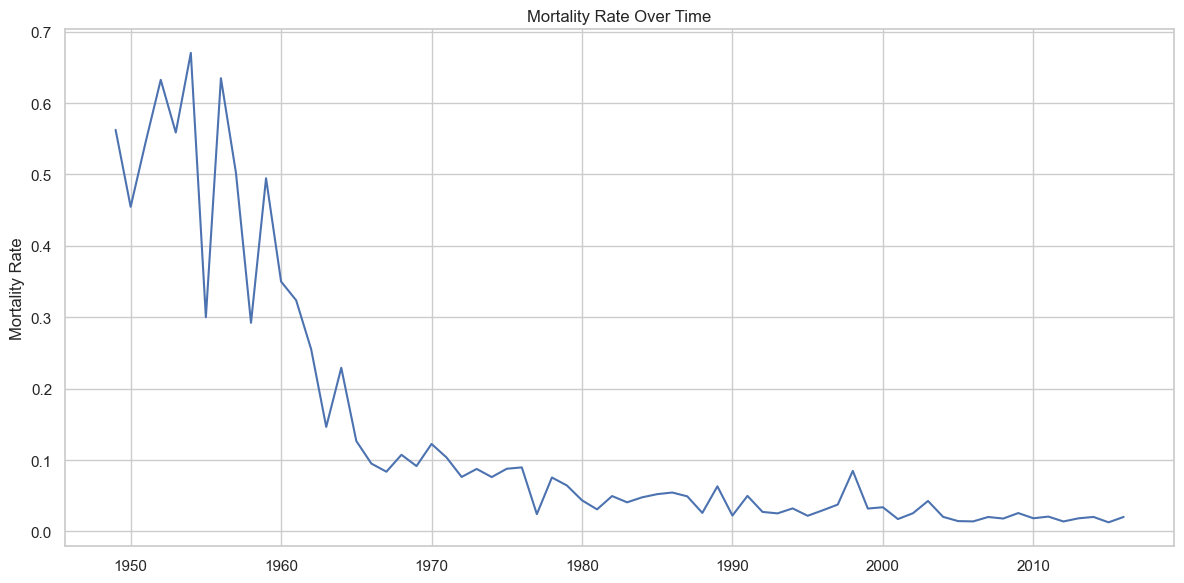

In [102]:
mortality_trend = df.groupby('Year')['mortality_rate'].mean()

plt.figure(figsize=(12,6))
plt.plot(mortality_trend)
plt.title("Mortality Rate Over Time")
plt.ylabel("Mortality Rate")
plt.tight_layout()
plt.show()


In [37]:
df.columns

Index(['Country', 'Year', 'Number of reported cases of cholera',
       'Number of reported deaths from cholera', 'Cholera case fatality rate',
       'WHO Region', 'recoveries', 'recovery_rate', 'mortality_rate',
       'period'],
      dtype='object')

**Moving avaerage (Simple prediction)**

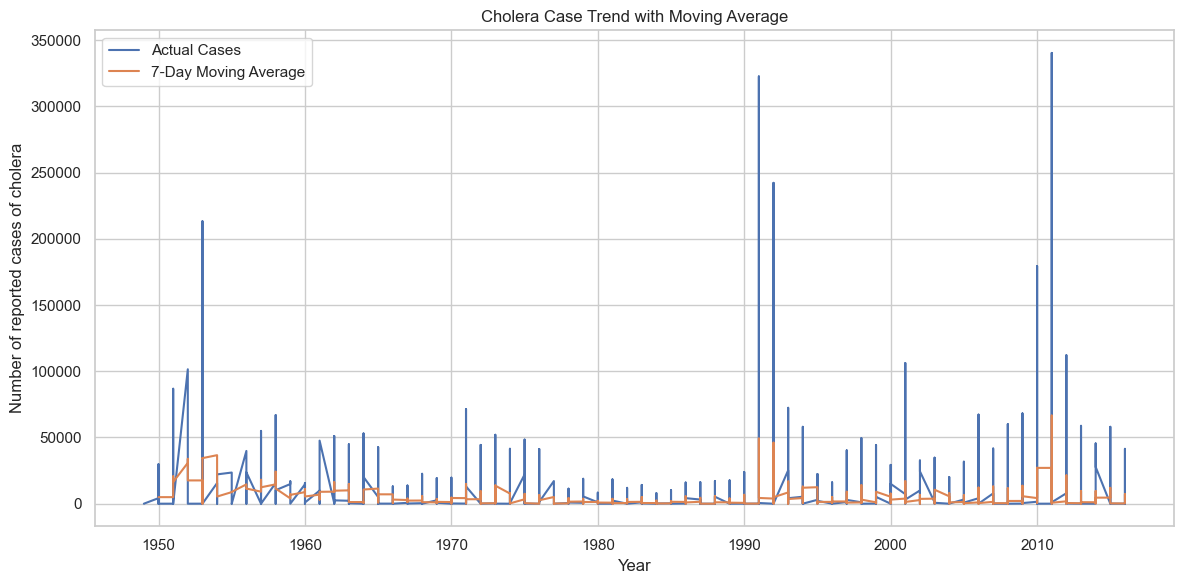

In [103]:
df = df.sort_values('Year')
df['cases_rolling'] = df['Number of reported cases of cholera'].rolling(window=7).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Year'], df['Number of reported cases of cholera'], label='Actual Cases')
plt.plot(df['Year'], df['cases_rolling'], label='7-Day Moving Average')

plt.legend()
plt.title("Cholera Case Trend with Moving Average")
plt.xlabel("Year")
plt.ylabel("Number of reported cases of cholera")
plt.tight_layout()
plt.show()

**Key insights print**

In [104]:
print("\n=== KEY INSIGHTS ===")

print("Total Cases:", df['Number of reported cases of cholera'].sum())
print("Total Deaths:", df['Number of reported deaths from cholera'].sum())
print("Total Recoveries:", df['recoveries'].sum())

print("\nHighest Cases Country:")
print(region_summary.idxmax(), "-", region_summary.max())

print("\nAverage Recovery Rate:", df['recovery_rate'].mean())
print("Average Mortality Rate:", df['mortality_rate'].mean())

print("\nPeak Cases Day:")
print(daily_trend.idxmax(), "-", daily_trend.max())


=== KEY INSIGHTS ===
Total Cases: 9180678.0
Total Deaths: 897204.0
Total Recoveries: 8283474.0

Highest Cases Country:
India - 1363250.0

Average Recovery Rate: 0.9156113484948962
Average Mortality Rate: 0.054693627428057126

Peak Cases Day:
1991 - 595334.0
